# Sujet 3 — Généralisation (Q1 → Q14)

> Équipe **BDD-MinArm** · Hackathon Albert School 2026 · Ministère des Armées.
> Identification navale **passive** (sans dépendre de l'AIS) + détection d'anomalies (faux pavillon, changement de nom, spoofing, AIS off, écart de position) + score de suspicion multi-facteurs + pipeline d'identification + enrichissement OSINT + fiche de renseignement LLM (Mistral) + carte folium.

Ce notebook **exécute** le livrable `reponses_generalisation.py` (≈ 60 s, toute la logique est dans `src/` — 20 modules), puis affiche les artefacts produits (`outputs/*.png`, `outputs/*.csv`, carte folium, graphe, fiche d'alerte, `outputs/results.json`). Les hypothèses & seuils : `docs/hypotheses.md`.

In [2]:
import sys, json
from pathlib import Path
import pandas as pd
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUT = ROOT / 'outputs'
pd.set_option('display.max_columns', 30)
from reponses_generalisation import main as gen_main

ModuleNotFoundError: No module named 'reponses_generalisation'

## Exécution du livrable `reponses_generalisation.py`

In [ ]:
gen_main()

INFO src.load: ships : 1000 navires (dont 491 suspects)


INFO src.load: radio : 5000 signatures, 994 MMSI distincts


INFO src.load: ais : 10000 lignes, 1000 MMSI, AIS_OFF=4987



  SUJET 3 — Généralisation (Q1 → Q14)
  Réponses produites par le pipeline ; toutes les hypothèses dans `docs/hypotheses.md`.

──────────────────────────────────────────────────────────────────────────────
  Préalable — chargement, EDA & contrôle qualité
──────────────────────────────────────────────────────────────────────────────


  Volumétrie : {'ships': [1000, 18], 'radio': [5000, 13], 'ais': [10000, 11], 'anom': [100, 7]}
  Manquants : {'ships': {'historical_names': 249}}
  Doublons : {'ships': 0, 'radio': 0, 'ais': 0, 'anom': 0}
  Hors-bornes : aucun
  Catégories hors-liste : aucune
  MMSI orphelins (radio/ais/anom) : 0/0/0
  Navires sans signature radio : 6 (['363951510', '435131361', '522451298', '534553120', '535117872', '675464001'])
  Structure — V Cramér nav_status↔status : 0.0313 | ais_active=True : 50.1%
  Vitesse implicite AIS : médiane 9.1 kn, max 12338.0 kn ⇒ positions = points aléatoires (pas des trajectoires)
  ⚠️ Plafond de rappel atteignable : 63% (37/100 anomalies Speed/Course non récupérables des tables)
  Actions de cleaning : 3 →
    • 6 navire(s) sans aucune signature radio → marqués `has_radio_signature=False` ; absents de ship_radio_profiles.csv ; utilisés comme signal de suspicion (« navire jamais entendu »).
    • Le champ `name` (dataset large) est un placeholder dérivé du MMSI (NAVI

...

INFO src.osint_enrich: Equasis : pas d'identifiants → renvoi vide.



──────────────────────────────────────────────────────────────────────────────
  Q12 — Pipeline d'identification passive (k-NN + One-Class SVM)
──────────────────────────────────────────────────────────────────────────────
Signature démo (vraie MMSI : 394819025)
  → mmsi prédit : 394819025 (confidence 0.203)
  → suspect : False | novelty_score : 2.661
  → raisons : ['Confiance k-NN faible (0.20) → MMSI candidat peu fiable.']
→ fiche  : outputs/alerte_465482524.md
→ alerte : /Users/predictingmed/Desktop/bdd minarm/sujet3/outputs/alerte_465482524.pdf

──────────────────────────────────────────────────────────────────────────────
  Q13 — Validation sur 10 signatures × 5 graines (leave-one-out)
──────────────────────────────────────────────────────────────────────────────


Taux d'identification correcte : 0.00% ± 0.00% (par graine : ['0%', '0%', '0%', '0%', '0%'])
Matrice de confusion [[TP, FN], [FP, TN]] : [[12, 12], [14, 12]]

──────────────────────────────────────────────────────────────────────────────
  Q14 — Mise à jour auto + ingestion OSINT (flux RSS)
──────────────────────────────────────────────────────────────────────────────


  https://gcaptain.com/feed/ → 12 items


  https://www.maritime-executive.com/articles.rss → 30 items
MMSI extraits des items RSS : [] ...
→ MMSI déjà connus dans le registre : 0

──────────────────────────────────────────────────────────────────────────────
  Pipeline terminé en 9.9 s.
  Synthèse → outputs/results.json



## Synthèse des résultats — `outputs/results.json`
Toutes les métriques clés produites par le pipeline (top freq, clustering, precision/recall par type d'anomalie, AUC du score uniforme vs tuné, XGBoost, benchmark PyOD, graphe, validation d'identification Q13…).

In [ ]:
results = json.loads((OUT / 'results.json').read_text())
print('Clés disponibles :', list(results.keys()))
print()
for k in ('q1_top5_freq', 'q2', 'q3', 'q4_eval', 'q5', 'q6', 'q7', 'q8',
          'q9', 'q10', 'q11', 'q13', 'score_uniform_weights', 'score_tuned',
          'xgboost', 'graph'):
    if k in results:
        print(f'{k:24} : {results[k]}')

Clés disponibles : ['data_quality', 'silent_ships', 'q1_top5_freq', 'q2', 'q3', 'q4_eval', 'q4_top10', 'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q11', 'score_uniform_weights', 'score_metrics', 'recall_by_type', 'score_tuned', 'xgboost', 'pyod_benchmark', 'graph', 'q13']

q1_top5_freq             : [{'mmsi': '211239944', 'name': 'NAVIRE-9944', 'flag': 'Singapore', 'freq_mean': 161.94, 'n_signatures': 1}, {'mmsi': '604969493', 'name': 'NAVIRE-9493', 'flag': 'China', 'freq_mean': 161.79, 'n_signatures': 1}, {'mmsi': '205927097', 'name': 'NAVIRE-7097', 'flag': 'France', 'freq_mean': 161.74, 'n_signatures': 1}, {'mmsi': '206352442', 'name': 'NAVIRE-2442', 'flag': 'USA', 'freq_mean': 161.6966666666667, 'n_signatures': 3}, {'mmsi': '637173265', 'name': 'NAVIRE-3265', 'flag': 'Denmark', 'freq_mean': 161.54, 'n_signatures': 1}]
q2                       : {'n_distinct_patterns': 6, 'patterns_with_count_1': [], 'n_unique_combinations': 330, 'unique_combinations_sample': [{'pulse_pattern': 'Continuous

### Q1 — Base de profils radio (`ship_radio_profiles.csv`)

In [ ]:
prof = pd.read_csv(ROOT / 'data' / 'processed' / 'ship_radio_profiles.csv')
print(f'{len(prof)} profils navire ; colonnes : {list(prof.columns)}')
prof.head()

994 profils navire ; colonnes : ['mmsi', 'freq_mean', 'freq_std', 'bandwidth_mean', 'bandwidth_std', 'power_mean', 'power_std', 'signal_strength_mean', 'signal_strength_std', 'snr_mean', 'snr_std', 'n_signatures', 'modulation_mode', 'modulation_entropy', 'pulse_pattern_mode', 'pulse_pattern_entropy', 'name', 'type', 'flag', 'is_suspicious', 'historical_names', 'n_names_historical']


,mmsi,freq_mean,freq_std,bandwidth_mean,bandwidth_std,power_mean,...,name,type,flag,is_suspicious,historical_names,n_names_historical
0,200698187,158.9000,1.608378,26.450000,15.286955,290.666667,...,NAVIRE-8187,Fishing Vessel,USA,False,NaN,0
1,201837657,159.2650,1.757791,22.066667,10.850561,164.716667,...,NAVIRE-7657,Fishing Vessel,Marshall Islands,False,"OLD_NAME_0, OLD_NAME_1",2
2,202156040,156.7800,0.390000,31.733333,17.011859,186.733333,...,NAVIRE-6040,Passenger Ship,Malta,True,NaN,0
3,203295373,158.5225,1.633429,37.950000,11.543108,80.125000,...,NAVIRE-5373,Bulk Carrier,Denmark,True,"OLD_NAME_0, OLD_NAME_1",2
4,204111655,158.5420,1.896041,39.840000,10.438055,271.700000,...,NAVIRE-1655,Bulk Carrier,Bahamas,True,"OLD_NAME_0, OLD_NAME_1",2


### Q3 — Clustering K-Means K=5 (+ Elbow / Silhouette)

,k,wcss,silhouette
0,2,2354.126,0.208
1,3,1938.766,0.214
2,4,1623.083,0.227
3,5,1445.870,0.224
4,6,1285.652,0.221
5,7,1195.624,0.225
6,8,1117.427,0.199
7,9,1046.931,0.212
8,10,982.079,0.214


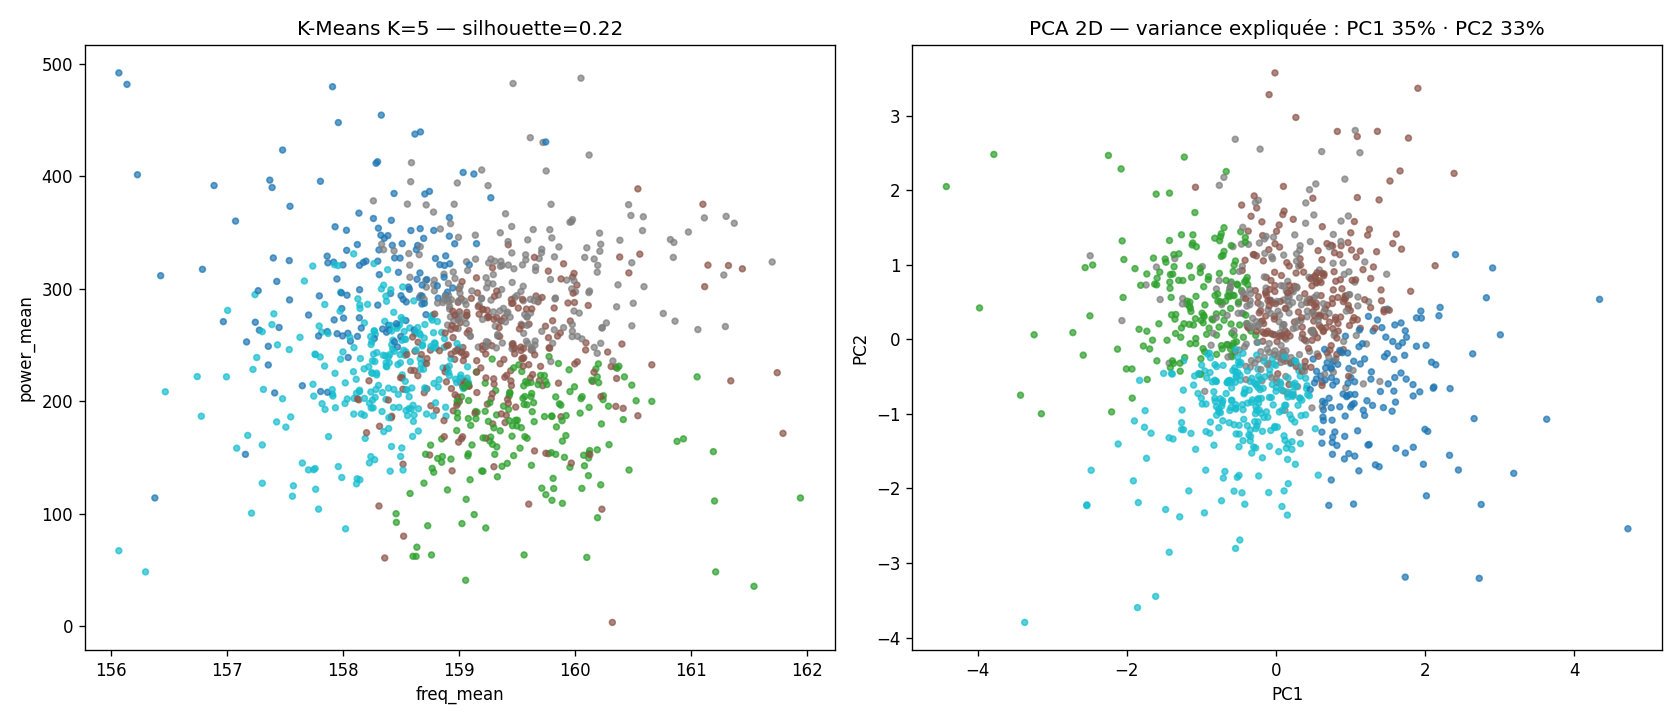

In [ ]:
from IPython.display import Image
display(pd.read_csv(OUT / 'q3_elbow_silhouette.csv').round(3))
Image(filename=str(OUT / 'clusters_kmeans.png'))

### Q4 — Anomalies de pavillon (EllipticEnvelope / MCD par flag) — top 10

In [ ]:
pd.read_csv(OUT / 'q4_fake_flag_report.csv').sort_values('confidence', ascending=False).head(10)

,mmsi,flag,mahalanobis,predicted,confidence,method
781,750940589,Panama,34.098180,-1,1.000000,EllipticEnvelope/MCD
25,383307372,Bahamas,76.992887,-1,1.000000,EllipticEnvelope/MCD
39,507138220,Bahamas,78.010993,-1,1.000000,EllipticEnvelope/MCD
754,580720286,Panama,51.768045,-1,1.000000,EllipticEnvelope/MCD
546,675737967,Malta,41.759352,-1,1.000000,EllipticEnvelope/MCD
574,798578134,Malta,22.873827,-1,1.000000,EllipticEnvelope/MCD
326,562875712,France,26.853123,-1,0.816040,EllipticEnvelope/MCD
801,225377906,Singapore,50.800126,-1,0.757093,EllipticEnvelope/MCD
579,231663168,Marshall Islands,26.341432,-1,0.728256,EllipticEnvelope/MCD
42,545105896,Bahamas,59.403058,-1,0.649680,EllipticEnvelope/MCD


### Q7 / Q8 — AIS désactivé > 24 h ; écart position AIS↔radio > 1 km

In [ ]:
blk = pd.read_csv(OUT / 'q7_ais_off_blocks.csv')
mis = pd.read_csv(OUT / 'q8_position_mismatch.csv')
print(f"Q7 — plages AIS off suspectes : {len(blk)} ; navires : {blk['mmsi'].nunique()}")
print(f"Q8 — paires en écart : {len(mis)} ; navires : {mis['mmsi'].nunique()}")
mis.head()

Q7 — plages AIS off suspectes : 215 ; navires : 203
Q8 — paires en écart : 261 ; navires : 235


,mmsi,timestamp_radio,timestamp_ais,lat_ais,lon_ais,lat_radio,lon_radio,distance_km
0,524295608,2026-01-03 20:00:00+00:00,2026-01-04 04:44:00+00:00,-15.3977,-153.9357,-78.3941,-82.3943,7924.709060
1,573145682,2026-01-04 13:00:00+00:00,2026-01-04 04:15:00+00:00,17.3799,-167.1454,79.6608,-60.2158,8443.903510
2,492381951,2026-01-06 05:00:00+00:00,2026-01-05 14:11:00+00:00,-70.8275,166.2404,54.6654,141.7068,14057.334996
3,638790258,2026-01-07 17:00:00+00:00,2026-01-06 17:35:00+00:00,-3.9183,-68.0102,55.6960,-170.9636,11176.734063
4,720463075,2026-01-08 00:00:00+00:00,2026-01-07 22:12:00+00:00,-57.7409,-76.7313,-1.4859,-174.9322,10354.671175


### Score de suspicion — rappel par type d'anomalie + ROC du score tuné

,type,n_truth,n_overlap,recall,recoverable,note
0,Spoofing,10,4,0.400,True,détecteur : 327 MMSI flaggés au total
1,Name Change,15,4,0.267,True,détecteur : 258 MMSI flaggés au total
2,Position Mismatch,14,3,0.214,True,détecteur : 235 MMSI flaggés au total
3,AIS Disabled,12,2,0.167,True,détecteur : 203 MMSI flaggés au total
4,Fake Flag,12,1,0.083,True,détecteur : 60 MMSI flaggés au total
5,Course Anomaly,21,0,0.000,False,non récupérable des tables (valeur seulement d...
6,Speed Anomaly,16,0,0.000,False,non récupérable des tables (valeur seulement d...


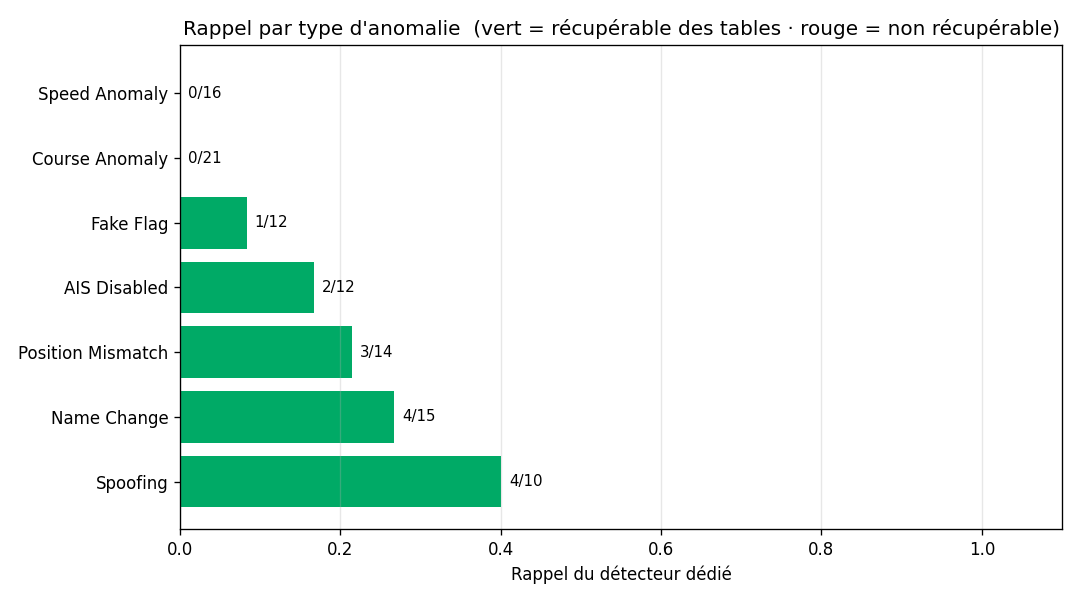

In [ ]:
display(pd.read_csv(OUT / 'recall_by_type.csv'))
Image(filename=str(OUT / 'recall_by_type.png'))

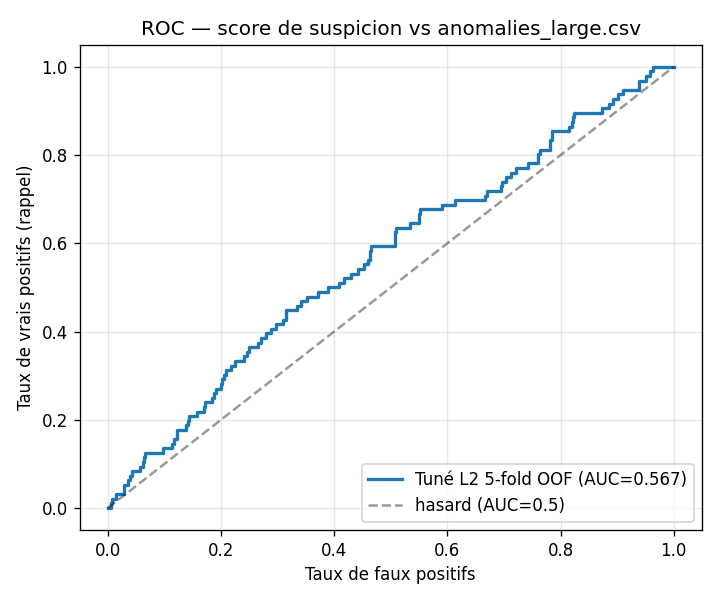

In [ ]:
Image(filename=str(OUT / 'roc_score_tuned.png'))

### XGBoost supervisé (force de proposition) + benchmark PyOD

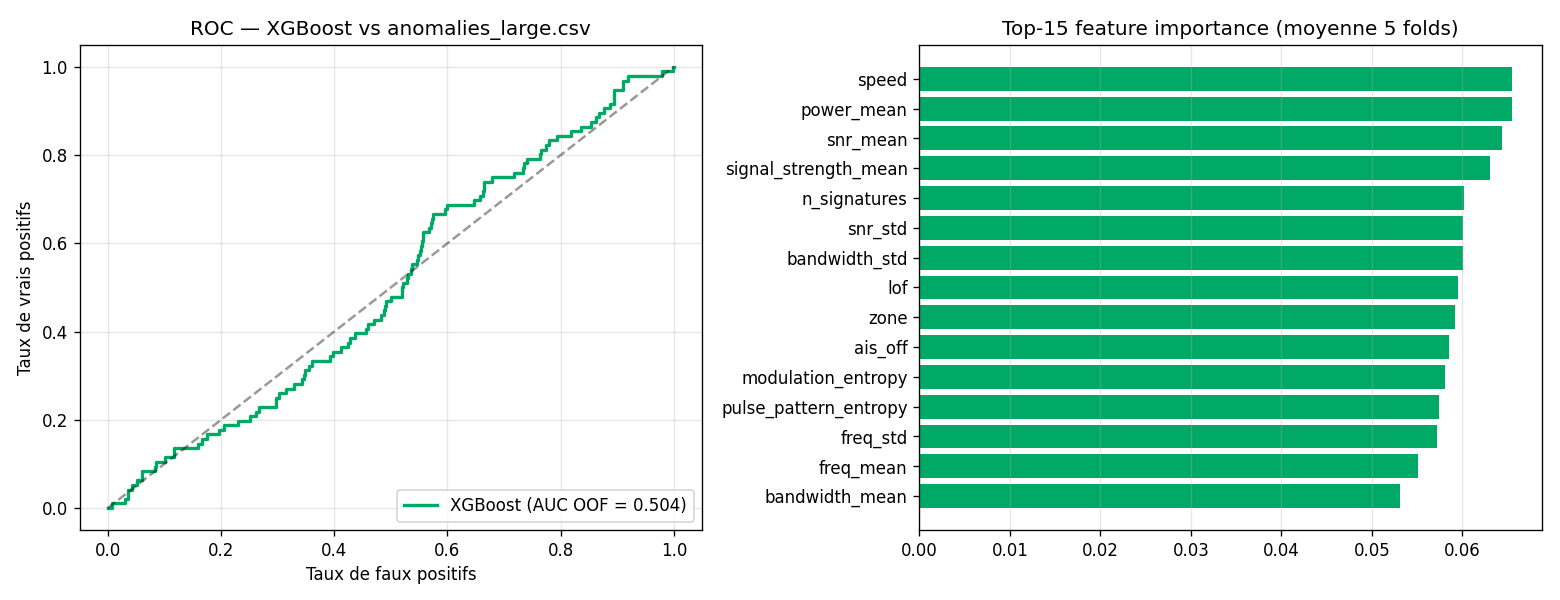

In [ ]:
Image(filename=str(OUT / 'roc_xgboost.png'))

In [ ]:
pd.read_csv(OUT / 'pyod_benchmark.csv')

,model,contamination,auc,precision_at_k,time_s,error
0,HBOS,0.02,0.528438,0.104167,0.76,NaN
1,COPOD,0.02,0.521801,0.125000,0.02,NaN
2,KNN,0.02,0.501429,0.135417,0.06,NaN
3,ECOD,0.02,0.491796,0.083333,0.58,NaN
4,PCA-OD,NaN,NaN,NaN,0.01,Input contains infinity or a value too large f...


### Q8 — Carte folium des écarts de position AIS↔radio (+ navires suspects)

In [ ]:
import IPython.display as _d
_d.IFrame(src=str((OUT / 'carte_anomalies.html').relative_to(ROOT)), width='100%', height=480)

NameError: name 'OUT' is not defined

### Graphe de connaissances NetworkX + pyvis (navires ↔ anomalies ↔ alertes)

In [ ]:
_d.IFrame(src=str((OUT / 'knowledge_graph.html').relative_to(ROOT)), width='100%', height=480)

### Q12 — Fiche de renseignement (LLM Mistral) générée pour le navire le plus suspect
Le pipeline génère un `outputs/alerte_<mmsi>.md` + un PDF. On affiche la fiche markdown :

In [ ]:
import glob
alertes = sorted(glob.glob(str(OUT / 'alerte_*.md')))
print('Fiches générées :', [Path(a).name for a in alertes])
if alertes:
    from IPython.display import Markdown
    display(Markdown((Path(alertes[-1]).read_text(encoding='utf-8'))))

Fiches générées : ['alerte_465482524.md', 'alerte_507138220.md', 'alerte_562875712.md']


# Fiche de renseignement — MMSI 562875712

*Générée par template Jinja2 (LLM indisponible).*

## Synthèse
Navire **NAVIRE-5712** (MMSI 562875712, IMO 1179171, pavillon **France**).
Score global d'anomalie : **0.61**.

## Indices de suspicion

- ⚠️ **3 noms historiques** (changements répétés).

- ⚠️ Marqué `is_suspicious` dans le registre de référence.
- Top raisons (score) : **spoofing_rules=1.50, ais_off=1.30, fake_flag=1.22**.

## Recommandation
Investigation OSINT approfondie recommandée si score ≥ 0.5, action consulaire
si score ≥ 0.7 et sanctions confirmées.

## Sources mobilisées
- Equasis · UIT MMSI / MARS · OpenSanctions · Cours A. Bogroff (Albert School).

## Récapitulatif

Voir `docs/cadrage.md` (cahier des charges), `docs/hypotheses.md` (seuils + justifications cours Bogroff / arXiv), `docs/plan-3-jours.md` (plan d'exécution). Le rapport complet aligné sur les 6 critères : `rapport_generalisation.md`. Pont narratif avec le Sujet 5 : « rendre visible un navire qui veut rester invisible — par ses émissions radio (S3) et depuis l'orbite (S5) ».